# 30 April 2026
- developing spectral model for CVs that is a one sided step function

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
#from sklearn.neighbors import KernelDensity
#from sklearn.model_selection import GridSearchCV
import copy
import corner
import pickle as pkl
import sys

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [4]:
pops_CV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_CVpop1_GBpop2_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))
pops_noCV_plot = pkl.load(open('../storage/run_outputs/prod_runs/dur12p6e7_inj_GBpop_rec_n_mwspecfixedgal/plot_data.pickle', 'rb'))
stepfunc_plot = pkl.load(open('/home/levis/lisa_projects/blip_CVs/storage/run_outputs/stepfuncdev/dur6p4e7_inj_onesstep4par_morebelown_ftst_fixedgal_rec_n_onesstep4parfixgal/2yr_i_onesstep4par_morebelown_ftst_fixgal_plot_data.pickle', 'rb'))


In [3]:
sys.path.append('/home/levis/lisa_projects/blip/blip/src/')
import submodel

In [17]:
stepfunc_plot['injspec_data'].keys()

dict_keys(['data_psd', 'noise_spectra', 'channels', 'onesidestep4par_fixedgalaxy'])

[]

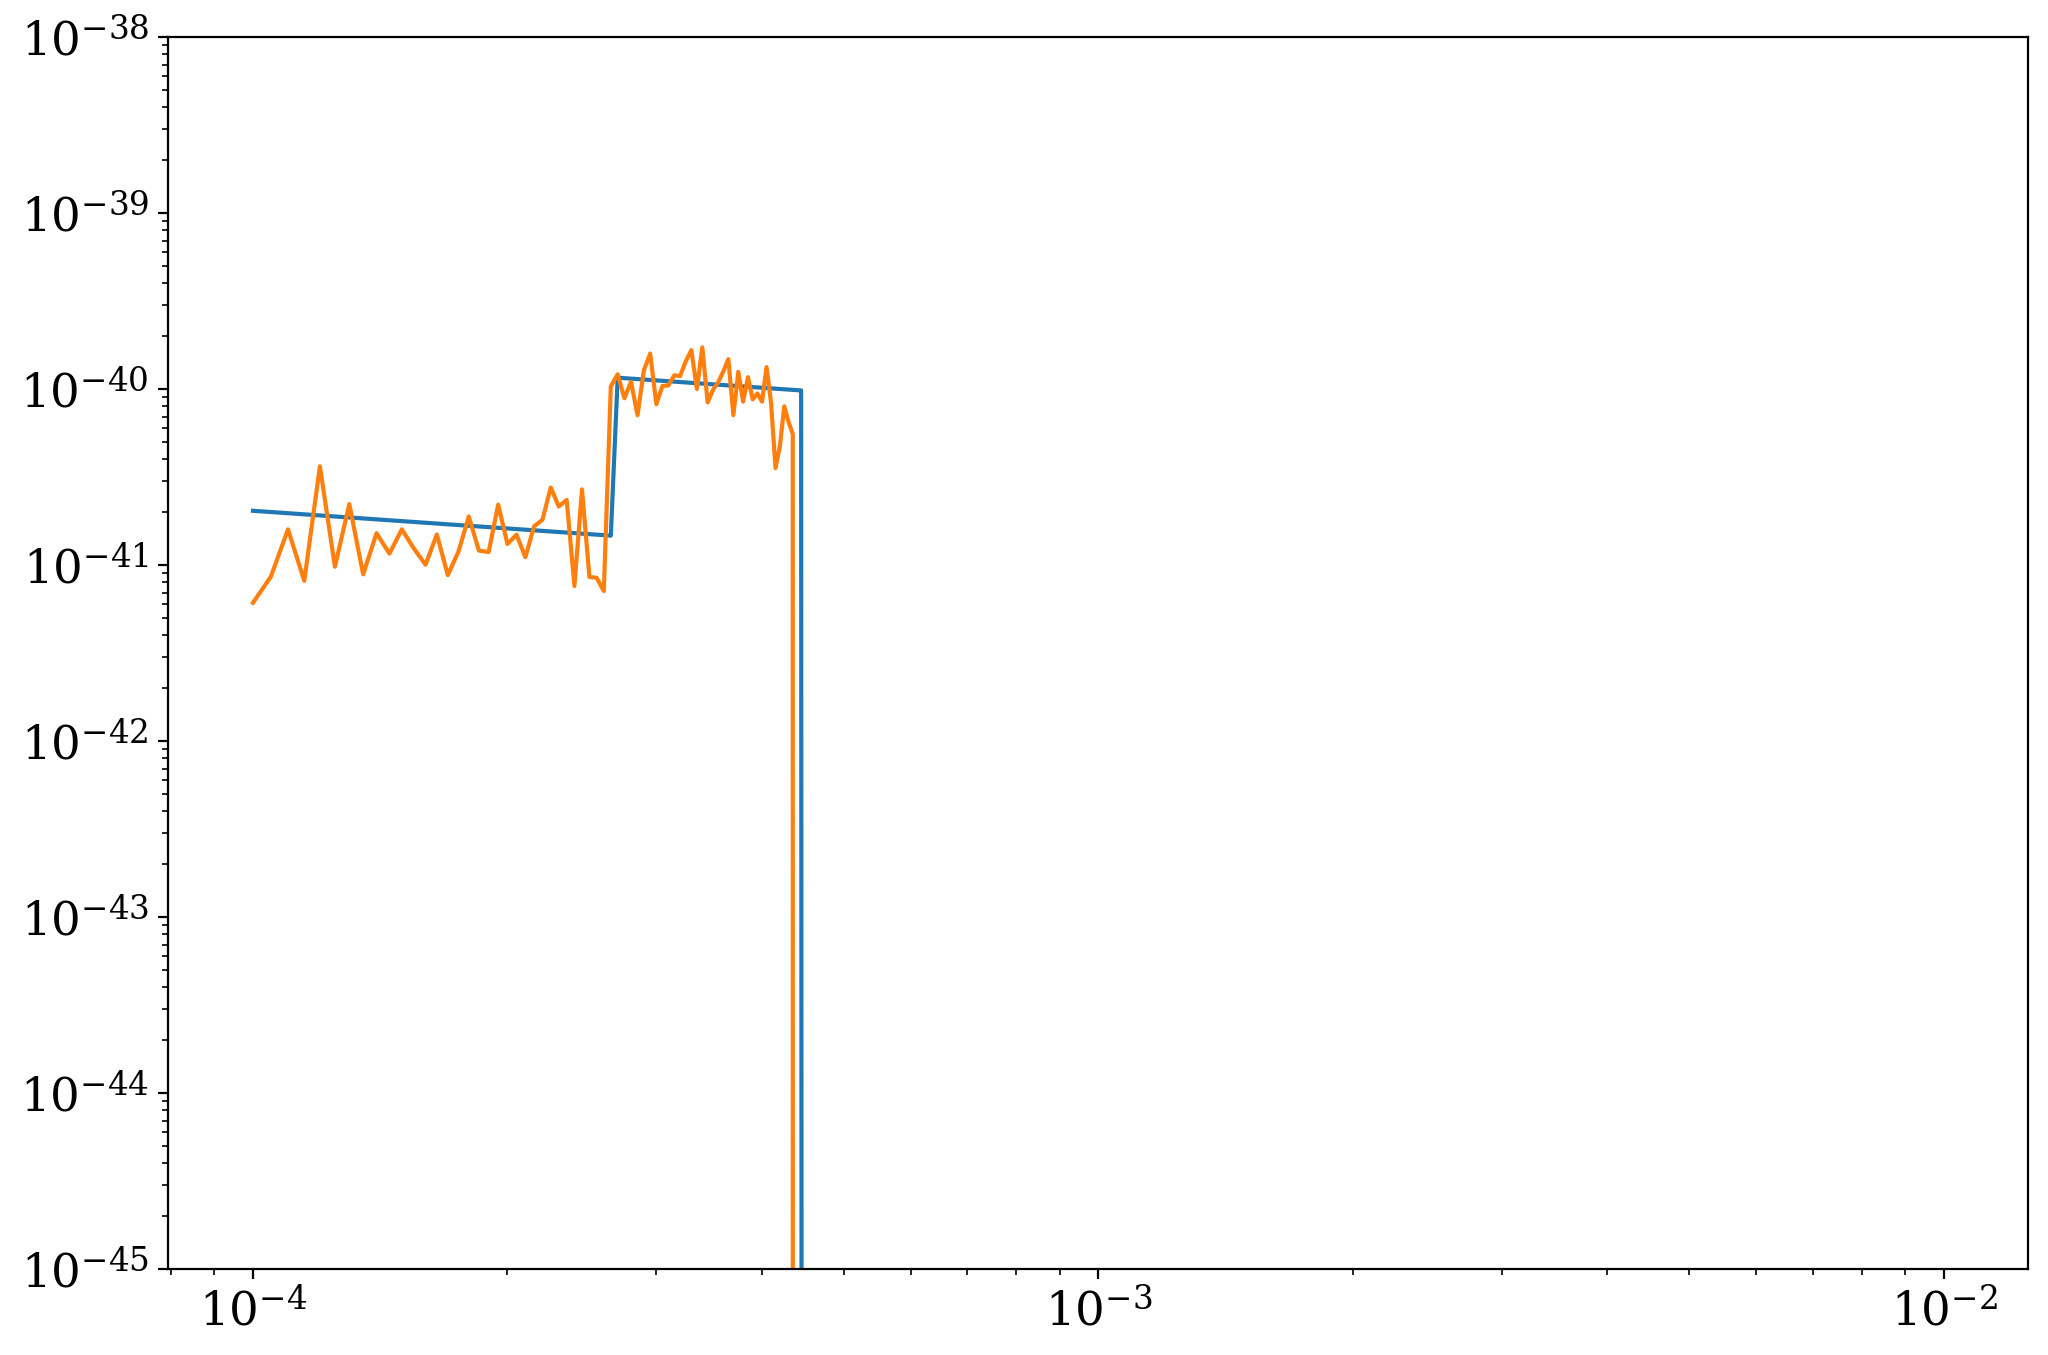

In [24]:
fig, ax = plt.subplots()


ax.plot(stepfunc_plot['injspec_data']['data_psd']['psdfreqs'], 3*stepfunc_plot['injspec_data']['onesidestep4par_fixedgalaxy']['S1_gw'], label='Step Function Population')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], pops_CV_plot['injspec_data']['population-1']['S1_gw'], label='CV Population')

plt.ylim(1e-45, 1e-38)
plt.loglog()

In [6]:
def oneside_step_fn_4par_spectrum(fs, logAmin, logAmax, logfmin, logfmax):
    Sgw = np.where(fs < 10**logfmin, 10**logAmin, 10**logAmax) * np.where(fs < 10**logfmax, 1, 1e-52)

    return Sgw

#submodel.compute_Omega0_from_Sgw(fs,Sgw)

In [5]:
fline = np.log10(3.5e-4) # LSS this is top of fmin prior and bottom of fmax prior
fminbot = np.log10(2e-4)
fmaxtop = np.log10(6e-4)

logAminbot = -48
logAmintop = -39 
logAmaxbot = -43
logAmaxtop = -35


tst = oneside_step_fn_4par_spectrum(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], -40.9, -40, np.log10(2.7e-4), np.log10(4.5e-4))
tstlow = oneside_step_fn_4par_spectrum(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], logAminbot, logAmaxbot, fminbot, fline)
tsthigh = oneside_step_fn_4par_spectrum(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], logAmintop, logAmaxtop, fline, fmaxtop)

NameError: name 'oneside_step_fn_4par_spectrum' is not defined

In [10]:
print(np.log10(2.7e-4))
print(np.log10(4.5e-4))

-3.5686362358410126
-3.3467874862246565


[]

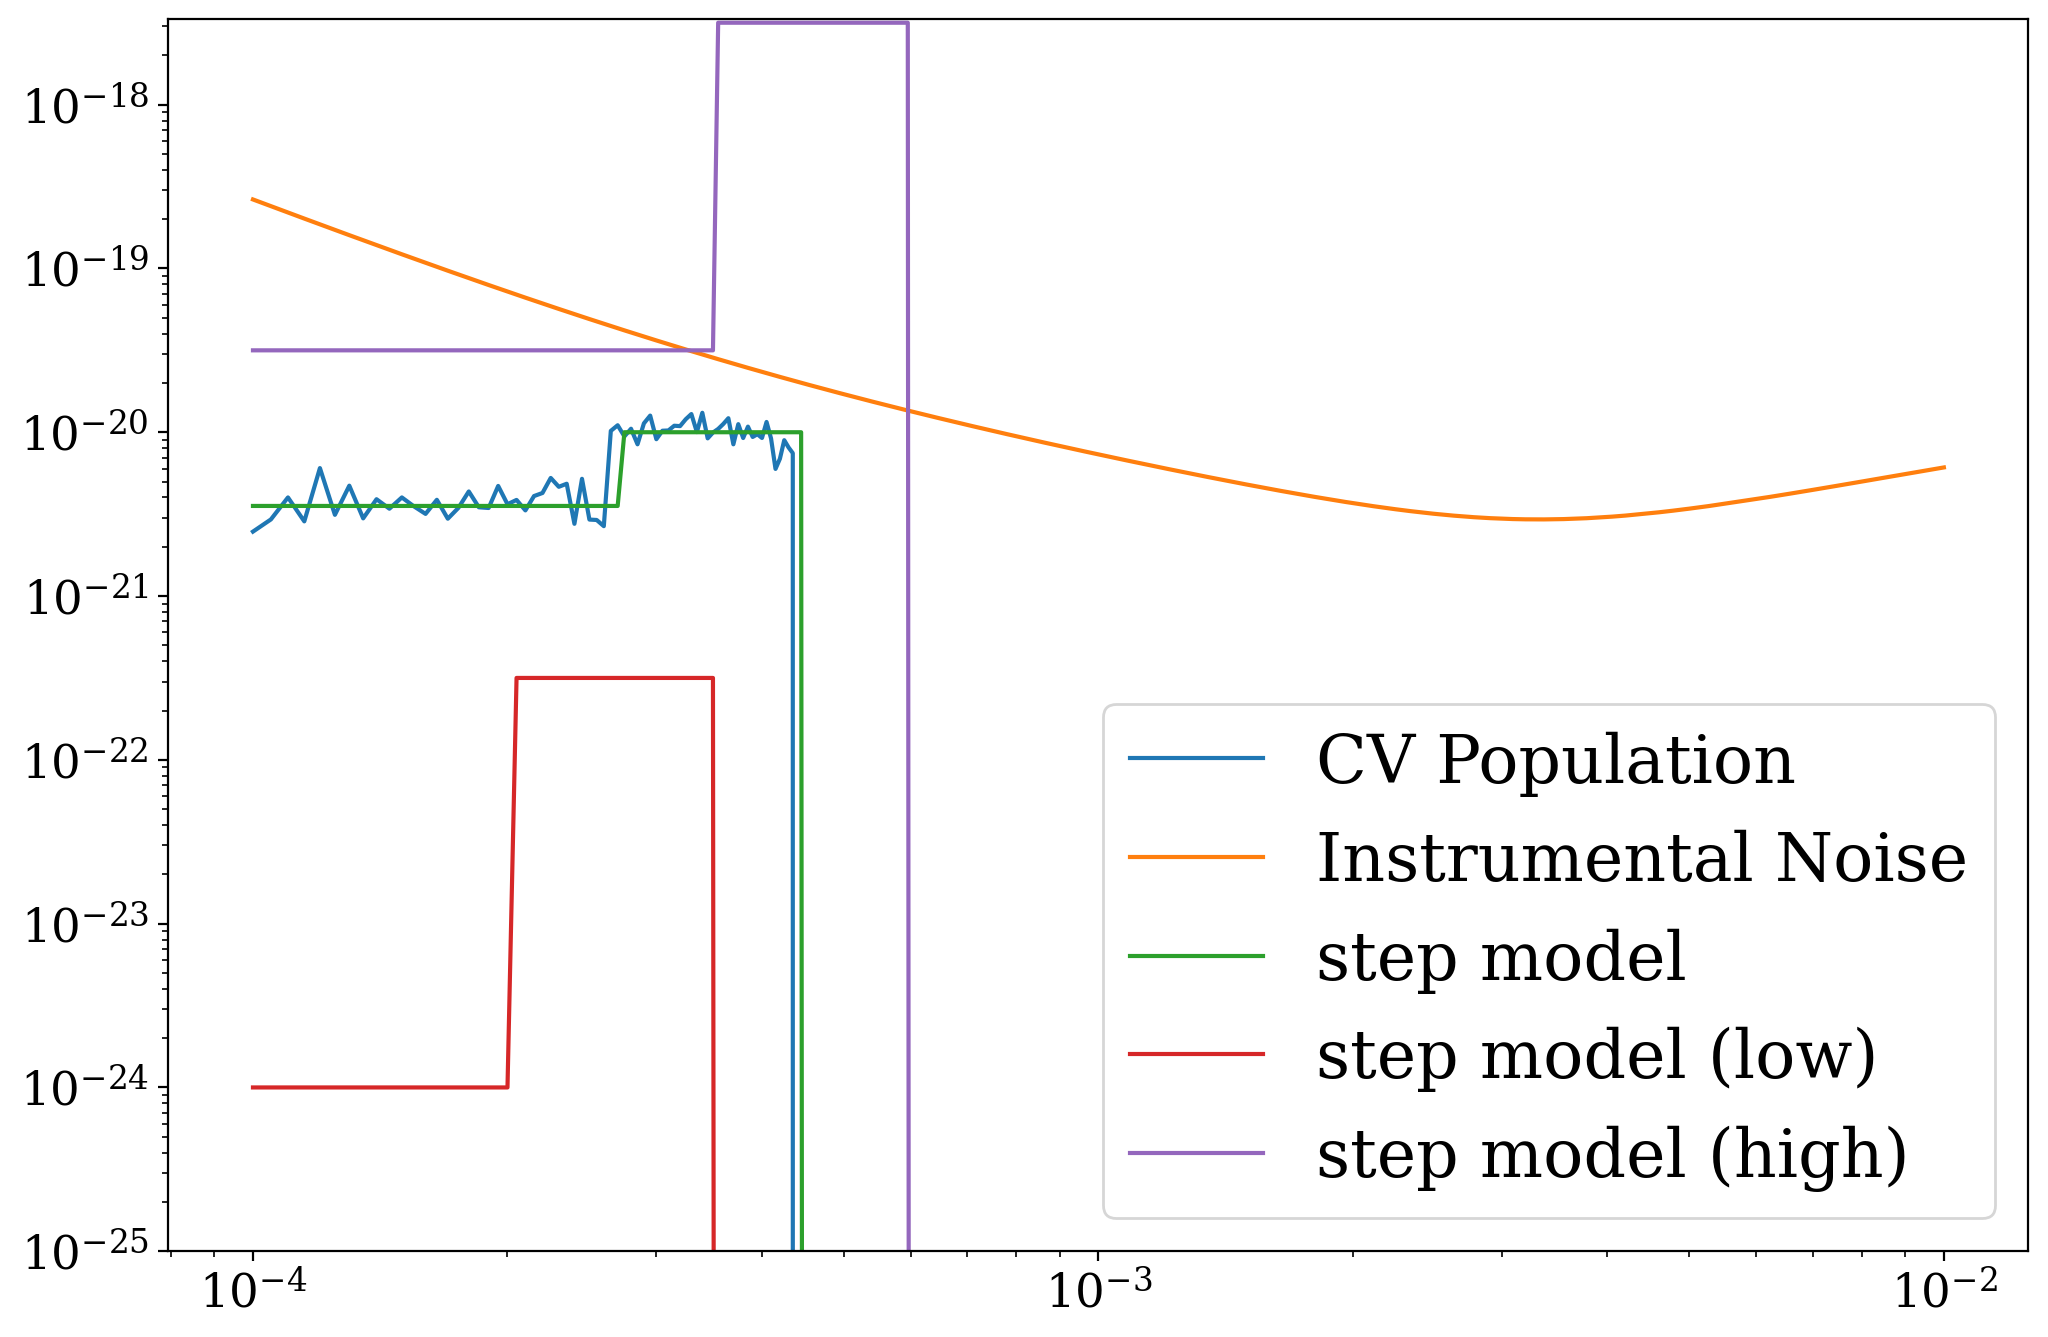

In [8]:
fig, ax = plt.subplots()


ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['population-1']['S1_gw']), label='CV Population')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(pops_CV_plot['injspec_data']['noise_spectra']['noise1']), label='Instrumental Noise')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(tst), label='step model')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(tstlow), label='step model (low)')
ax.plot(pops_CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(tsthigh), label='step model (high)')
ax.set_ylim(1e-25, None)
#ax.set_xlim(1e-5, None)
plt.legend()
plt.loglog()